
# Application in real options theory

Run the notebook from top to bottom to regenerate all figures appearing in the "Comparison to Real Options Theory" section, following each step of the derivation as you go.



## Discrete‑Payoff Real Option under Robustness  

We consider an investor who holds an irreversible **option** that, once exercised, pays  

$$
Y_{\,\tau} - I,
$$

where the income process follows  

$$
dY_t \;=\; \alpha\,dt \;+\; \sigma\,dW_t,
$$

and $I>0$ is the exercise cost.  
Under multiplier preferences, the pre‑exercise value is conjectured to be  

$$
V(w,y)\;=\;\delta\,[\,w \;+\; G(y)\,],
$$

and the robust‑control Hamilton–Jacobi–Bellman (HJB) equation collapses to the nonlinear ODE  

$$
0\;=\;-\delta G
   \;+\; \alpha\,G_y
   \;+\;\frac{\sigma^2}{2}G_{yy}
   \;-\;\frac{\sigma^2\delta}{2\xi}\bigl(G_y\bigr)^2 .
$$

The exercise threshold $\bar y(\xi)$ is pinned down by the usual **value‑matching** and **smooth‑pasting** conditions  

$$
\delta\,G(\bar y)\;=\;\bar y+\frac{\alpha}{\delta}-\delta I,
\quad\qquad
\delta\,G_y(\bar y)\;=\;1.
$$

The code block below solves this boundary‑value problem numerically, traces $\delta G_y(y)$, and computes $\bar y(\xi)$ for the figure.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

# Define the system of ODEs
def odes(y, U, delta, sigma, alpha, xi):
    G, H = U
    dG_dy = H
    dH_dy = (2 / sigma**2) * (delta * G - H * alpha + (delta*sigma**2 / (2 * xi)) * H**2)
    return np.vstack([dG_dy, dH_dy])

# Wrapper function to fix parameters for solve_bvp
def odes_fixed(y, U):
    return odes(y, U, delta, sigma, alpha, xi)

# Define boundary conditions
def bc(Ua, Ub, y_bar, I):
    Ga, Ha = Ua  # Values at left boundary
    Gb, Hb = Ub  # Values at right boundary
    return np.array([Ga, Gb - (y_bar/delta - I+ alpha/delta**2)])

# Wrapper function to fix parameters for solve_bvp
def bc_fixed(Ua, Ub):
    return bc(Ua, Ub, y_bar, I)

# Parameters (adjust as needed)
delta = 0.02  # Example value for delta
sigma = 0.3  # Example value for sigma
alpha = 0.1  # Example value for alpha
xi = 1000.0  # Example value for xi
y_bar = 0.62  # Example boundary point
I = 10 #  Example boundary value

# Define the domain for y
y_min, y_max = -100, y_bar  # Large negative value to approximate -∞
y = np.linspace(y_min, y_max, 1000)  # Discretize y-space with 100 points

# Initial guess for G and H
U_init = np.zeros((2, y.size))

# Solve the BVP
sol = solve_bvp(odes_fixed, bc_fixed, y, U_init)

Gy_sol = sol.y[0]
Hy_sol = sol.y[1]

print('Solution of the ODE system:')
# print('G(y) =', Gy_sol) 
print('H(y) =', Hy_sol[-1])

plt.figure(figsize=(8, 5))
plt.plot(sol.x[sol.x>-5], sol.y[0][sol.x>-5], label=r'$G(y)$')
# plt.plot(sol.x[sol.x>-5], sol.x[sol.x>-5]-I, label=r'$G(y)$')
# plt.plot(sol.x, sol.y[1], label=r'$H(y)$')
plt.xlabel(r'$y$')
plt.ylabel(r'Function values')
# plt.ylim(0, 6)
plt.legend()
plt.title('Solution of the ODE System')
# plt.grid()
plt.show()



In [38]:
### Plot of ybar over xi




import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp


delta = 0.02  # Example value for delta
sigma = 0.3  # Example value for sigma
alpha = 0.1  # Example value for alpha
I = 10 #  Example boundary value


save_list_xi =[]
save_list_y_bar = []
save_list_Gprime = []
save_list_y_list = []
save_list_h_distortion =[]

xi_list = np.arange(1,40,1)
xi_list = np.append(xi_list,10000)
for xi_values in xi_list:


    def one_time_solve(y_bar=15,xi=10000):
        # Define the system of ODEs
        def odes(y, U, delta, sigma, alpha, xi):
            G, H = U
            dG_dy = H
            dH_dy = (2 / sigma**2) * (delta * G - H * alpha + (delta*sigma**2 / (2 * xi)) * H**2)
            return np.vstack([dG_dy, dH_dy])

        # Wrapper function to fix parameters for solve_bvp
        def odes_fixed(y, U):
            return odes(y, U, delta, sigma, alpha, xi)

        # Define boundary conditions
        def bc(Ua, Ub, y_bar, I):
            Ga, Ha = Ua  # Values at left boundary
            Gb, Hb = Ub  # Values at right boundary
            return np.array([Ga, Gb - (y_bar/delta - I+ alpha/delta**2)])

        # Wrapper function to fix parameters for solve_bvp
        def bc_fixed(Ua, Ub):
            return bc(Ua, Ub, y_bar, I)


        # Define the domain for y
        y_min, y_max = -100, y_bar  # Large negative value to approximate -∞
        y = np.linspace(y_min, y_max, 1000)  # Discretize y-space with 100 points

        # Initial guess for G and H
        U_init = np.zeros((2, y.size))

        # Solve the BVP
        sol = solve_bvp(odes_fixed, bc_fixed, y, U_init)

        Gy_sol = sol.y[0]
        Hy_sol = sol.y[1]
        
        h_sol = -sigma/xi * Hy_sol*delta
        
        return Gy_sol, Hy_sol,y,h_sol

    if xi_values>4:
        y_bar_list = np.arange(0, 1, 0.01)
    else:
        if xi_values<1.5:
            y_bar_list = np.arange(-5, 0, 0.01)
        else:
            y_bar_list = np.arange(-1, 1, 0.01)

    results = []

    for y_bar_value in y_bar_list:
        _,temp_H,_,_ = one_time_solve(y_bar=y_bar_value,xi=xi_values)
        results.append(temp_H)

    results=np.array(results)


    min_index = np.argmin(np.abs(results[:,-1]-1/delta))
    min_result = results[min_index,-1]
    min_y_bar = y_bar_list[min_index]

    save_list_xi.append(xi_values)
    save_list_y_bar.append(min_y_bar)
    print('xi value:',xi_values,'The found value of H(y) is', min_result, 'at y_bar =', min_y_bar)  
    

    save_list_Gprime.append(one_time_solve(y_bar=min_y_bar,xi=xi_values)[1])
    save_list_y_list.append(one_time_solve(y_bar=min_y_bar,xi=xi_values)[2])
    save_list_h_distortion.append(one_time_solve(y_bar=min_y_bar,xi=xi_values)[3])

save_list_xi = np.array(save_list_xi)
save_list_y_bar = np.array(save_list_y_bar)
save_list_Gprime = np.array(save_list_Gprime)
save_list_y_list = np.array(save_list_y_list)
save_list_h_distortion = np.array(save_list_h_distortion)


import pandas as pd

# Create a DataFrame
df = pd.DataFrame({"xi": save_list_xi, "y_bar": save_list_y_bar})

# Save as CSV
df.to_csv("model1_solution_xi_ybar.csv", index=False)


xi value: 1 The found value of H(y) is 50.096411919802534 at y_bar = -1.0800000000000836
xi value: 2 The found value of H(y) is 49.94743993520084 at y_bar = -0.3099999999999994
xi value: 3 The found value of H(y) is 50.02844220982819 at y_bar = -0.00999999999999912
xi value: 4 The found value of H(y) is 50.000270661497765 at y_bar = 0.140000000000001
xi value: 5 The found value of H(y) is 49.96815409048264 at y_bar = 0.23
xi value: 6 The found value of H(y) is 50.04616469380097 at y_bar = 0.3
xi value: 7 The found value of H(y) is 49.99371395382452 at y_bar = 0.34
xi value: 8 The found value of H(y) is 49.954112499148096 at y_bar = 0.37
xi value: 9 The found value of H(y) is 49.98994790111913 at y_bar = 0.4
xi value: 10 The found value of H(y) is 49.977767476516476 at y_bar = 0.42
xi value: 11 The found value of H(y) is 50.00348448528226 at y_bar = 0.44
xi value: 12 The found value of H(y) is 49.95897206981912 at y_bar = 0.45
xi value: 13 The found value of H(y) is 50.03423837299698 at

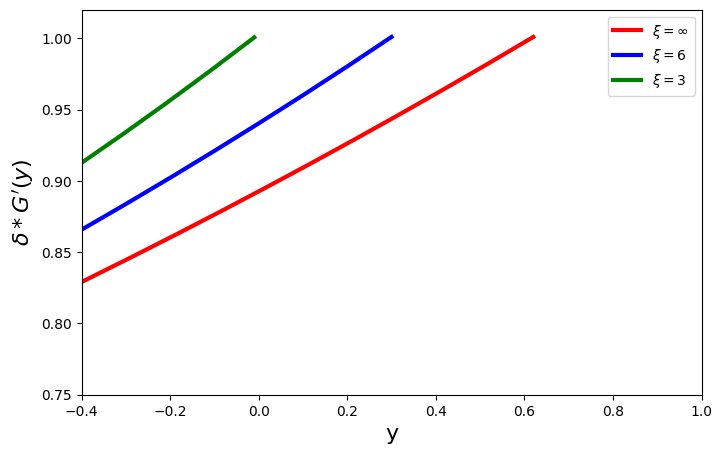

In [45]:

plt.figure(figsize=(8, 5))
plt.plot(save_list_y_list[save_list_xi==10000,:][0,:], delta*save_list_Gprime[save_list_xi==10000,:][0,:], label=r"$\xi=\infty$",linewidth =3,color='r')
# plt.plot(save_list_y_list[save_list_xi==10,:][0,:], delta*save_list_Gprime[save_list_xi==10,:][0,:], label=r"$\xi=10$",linewidth =3,color='y')
plt.plot(save_list_y_list[save_list_xi==6,:][0,:], delta*save_list_Gprime[save_list_xi==6,:][0,:], label=r"$\xi=6$",linewidth =3,color='b')
plt.plot(save_list_y_list[save_list_xi==3,:][0,:], delta*save_list_Gprime[save_list_xi==3,:][0,:], label=r"$\xi=3$",linewidth =3,color='g')
plt.ylabel(r"$\delta*G'(y)$",fontsize=16)
plt.xlabel(r'y',fontsize=16)
plt.xlim(-0.4, 1)
plt.ylim(0.75,1.02)
plt.legend()
plt.savefig("model1_derivative.png")
# plt.title('Solution of the ODE System')
# plt.grid()
plt.show()


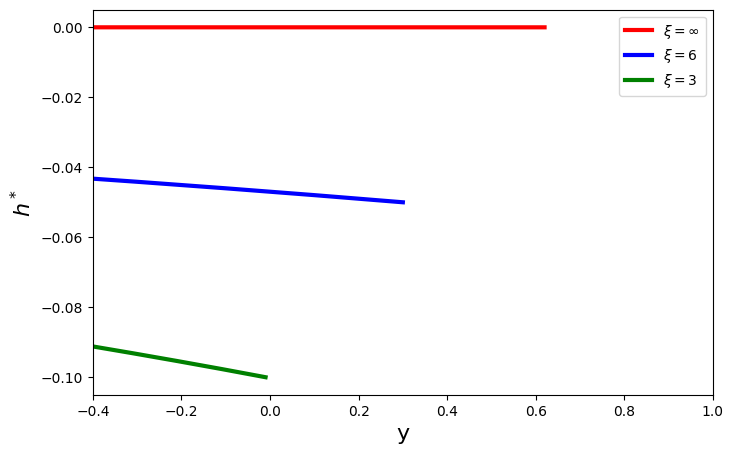

In [46]:

plt.figure(figsize=(8, 5))
plt.plot(save_list_y_list[save_list_xi==10000,:][0,:], save_list_h_distortion[save_list_xi==10000,:][0,:], label=r"$\xi=\infty$",linewidth =3,color='r')
# plt.plot(save_list_y_list[save_list_xi==20,:][0,:], save_list_Gprime[save_list_xi==20,:][0,:], label=r"$\xi=20$",linewidth =3,color='y')
plt.plot(save_list_y_list[save_list_xi==6,:][0,:], save_list_h_distortion[save_list_xi==6,:][0,:], label=r"$\xi=6$",linewidth =3,color='b')
plt.plot(save_list_y_list[save_list_xi==3,:][0,:], save_list_h_distortion[save_list_xi==3,:][0,:], label=r"$\xi=3$",linewidth =3,color='g')
plt.ylabel(r"$h^*$",fontsize=16)
plt.xlabel(r'y',fontsize=16)
plt.xlim(-0.4, 1)
# plt.ylim(0.75,1.02)
plt.legend()
plt.savefig("model1_distortion.png")
# plt.title('Solution of the ODE System')
# plt.grid()
plt.show()


In [ ]:
########### Adjust I
### Plot of ybar over xi




import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp


delta = 0.02  # Example value for delta
sigma = 0.3  # Example value for sigma
alpha = 0.1  # Example value for alpha
I = 5 #  Example boundary value


save_list_xi =[]
save_list_y_bar = []

xi_list = np.arange(1,40,1)
for xi_values in xi_list:


    def one_time_solve(y_bar=15,xi=10000):
        # Define the system of ODEs
        def odes(y, U, delta, sigma, alpha, xi):
            G, H = U
            dG_dy = H
            dH_dy = (2 / sigma**2) * (delta * G - H * alpha + (delta*sigma**2 / (2 * xi)) * H**2)
            return np.vstack([dG_dy, dH_dy])

        # Wrapper function to fix parameters for solve_bvp
        def odes_fixed(y, U):
            return odes(y, U, delta, sigma, alpha, xi)

        # Define boundary conditions
        def bc(Ua, Ub, y_bar, I):
            Ga, Ha = Ua  # Values at left boundary
            Gb, Hb = Ub  # Values at right boundary
            return np.array([Ga, Gb - (y_bar/delta - I+ alpha/delta**2)])

        # Wrapper function to fix parameters for solve_bvp
        def bc_fixed(Ua, Ub):
            return bc(Ua, Ub, y_bar, I)


        # Define the domain for y
        y_min, y_max = -100, y_bar  # Large negative value to approximate -∞
        y = np.linspace(y_min, y_max, 1000)  # Discretize y-space with 100 points

        # Initial guess for G and H
        U_init = np.zeros((2, y.size))

        # Solve the BVP
        sol = solve_bvp(odes_fixed, bc_fixed, y, U_init)

        Gy_sol = sol.y[0]
        Hy_sol = sol.y[1]
        
        h_sol = -sigma/xi * Hy_sol*delta
        
        return Gy_sol, Hy_sol,y,h_sol


    y_bar_list = np.arange(-5, 5, 0.01)


    results = []

    for y_bar_value in y_bar_list:
        _,temp_H,_,_ = one_time_solve(y_bar=y_bar_value,xi=xi_values)
        results.append(temp_H)

    results=np.array(results)


    min_index = np.argmin(np.abs(results[:,-1]-1/delta))
    min_result = results[min_index,-1]
    min_y_bar = y_bar_list[min_index]

    save_list_xi.append(xi_values)
    save_list_y_bar.append(min_y_bar)
    print('xi value:',xi_values,'The found value of H(y) is', min_result, 'at y_bar =', min_y_bar)  

save_list_xi = np.array(save_list_xi)
save_list_y_bar = np.array(save_list_y_bar)




import pandas as pd

# Create a DataFrame
df = pd.DataFrame({"xi": save_list_xi, "y_bar": save_list_y_bar})

# Save as CSV
df.to_csv("model1_solution_xi_ybar_I5.csv", index=False)


In [ ]:
### Plot of ybar over xi




import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp


delta = 0.02  # Example value for delta
sigma = 0.3  # Example value for sigma
alpha = 0.1  # Example value for alpha
I = 15 #  Example boundary value


save_list_xi =[]
save_list_y_bar = []

xi_list = np.arange(1,40,1)
for xi_values in xi_list:


    def one_time_solve(y_bar=15,xi=10000):
        # Define the system of ODEs
        def odes(y, U, delta, sigma, alpha, xi):
            G, H = U
            dG_dy = H
            dH_dy = (2 / sigma**2) * (delta * G - H * alpha + (delta*sigma**2 / (2 * xi)) * H**2)
            return np.vstack([dG_dy, dH_dy])

        # Wrapper function to fix parameters for solve_bvp
        def odes_fixed(y, U):
            return odes(y, U, delta, sigma, alpha, xi)

        # Define boundary conditions
        def bc(Ua, Ub, y_bar, I):
            Ga, Ha = Ua  # Values at left boundary
            Gb, Hb = Ub  # Values at right boundary
            return np.array([Ga, Gb - (y_bar/delta - I+ alpha/delta**2)])

        # Wrapper function to fix parameters for solve_bvp
        def bc_fixed(Ua, Ub):
            return bc(Ua, Ub, y_bar, I)


        # Define the domain for y
        y_min, y_max = -100, y_bar  # Large negative value to approximate -∞
        y = np.linspace(y_min, y_max, 1000)  # Discretize y-space with 100 points

        # Initial guess for G and H
        U_init = np.zeros((2, y.size))

        # Solve the BVP
        sol = solve_bvp(odes_fixed, bc_fixed, y, U_init)

        Gy_sol = sol.y[0]
        Hy_sol = sol.y[1]
        
        h_sol = -sigma/xi * Hy_sol*delta
        
        return Gy_sol, Hy_sol,y,h_sol


    y_bar_list = np.arange(-5, 5, 0.01)


    results = []

    for y_bar_value in y_bar_list:
        _,temp_H,_,_ = one_time_solve(y_bar=y_bar_value,xi=xi_values)
        results.append(temp_H)

    results=np.array(results)


    min_index = np.argmin(np.abs(results[:,-1]-1/delta))
    min_result = results[min_index,-1]
    min_y_bar = y_bar_list[min_index]

    save_list_xi.append(xi_values)
    save_list_y_bar.append(min_y_bar)
    print('xi value:',xi_values,'The found value of H(y) is', min_result, 'at y_bar =', min_y_bar)  

save_list_xi = np.array(save_list_xi)
save_list_y_bar = np.array(save_list_y_bar)




import pandas as pd

# Create a DataFrame
df = pd.DataFrame({"xi": save_list_xi, "y_bar": save_list_y_bar})

# Save as CSV
df.to_csv("model1_solution_xi_ybar_I15.csv", index=False)



## Flow‑Payoff Real Option under Robustness  

Here exercising the option grants a perpetual **cash‑flow** equal to the income process $Y_t$ itself.  
The post‑exercise problem is analytically tractable and yields  

$$
V^{\text{o}}(w,y)\;=\;\delta\bigl[w + F(y)\bigr], 
\qquad
F(y)\;=\;\frac1\delta\!\left(y + \frac{\alpha}{\delta} - \frac{\sigma^2}{2\xi\delta}\right).
$$

Before exercise, $G$ satisfies the same ODE as in the previous model, but value matching becomes  

$$
\delta\,G(\bar y)\;=\;\bar y + \frac{\alpha}{\delta} 
        - \frac{\sigma^2}{2\xi\delta} - \delta I,
$$

while smooth pasting still imposes $\delta\,G_y(\bar y)=1$.  
Because **uncertainty persists after exercise**, stronger aversion (smaller $\xi$) *raises* the threshold, reversing the comparative‑statics of Model 1.


Solution of the ODE system:
H(y) = 55.850448132899956


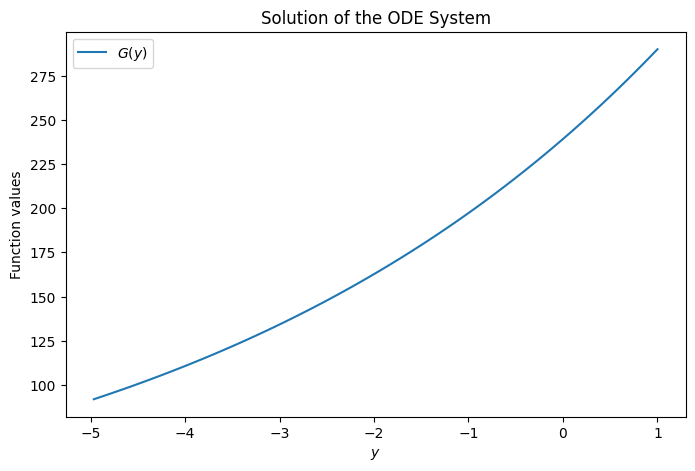

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

# Define the system of ODEs
def odes(y, U, delta, sigma, alpha, xi):
    G, H = U
    dG_dy = H
    dH_dy = (2 / sigma**2) * (delta * G - H * alpha + (delta*sigma**2 / (2 * xi)) * H**2)
    return np.vstack([dG_dy, dH_dy])

# Wrapper function to fix parameters for solve_bvp
def odes_fixed(y, U):
    return odes(y, U, delta, sigma, alpha, xi)

# Define boundary conditions
def bc(Ua, Ub, y_bar, I):
    Ga, Ha = Ua  # Values at left boundary
    Gb, Hb = Ub  # Values at right boundary
    return np.array([Ga, Gb - (y_bar/delta - I+ alpha/delta**2-sigma**2/(2*xi*delta**2))])

# Wrapper function to fix parameters for solve_bvp
def bc_fixed(Ua, Ub):
    return bc(Ua, Ub, y_bar, I)

# Parameters (adjust as needed)
delta = 0.02  # Example value for delta
sigma = 0.2  # Example value for sigma
alpha = 0.1  # Example value for alpha
xi = 1000.0  # Example value for xi
y_bar = 1  # Example boundary point
I = 10 #  Example boundary value

# Define the domain for y
y_min, y_max = -100, y_bar  # Large negative value to approximate -∞
y = np.linspace(y_min, y_max, 1000)  # Discretize y-space with 100 points

# Initial guess for G and H
U_init = np.zeros((2, y.size))

# Solve the BVP
sol = solve_bvp(odes_fixed, bc_fixed, y, U_init)

Gy_sol = sol.y[0]
Hy_sol = sol.y[1]

print('Solution of the ODE system:')
# print('G(y) =', Gy_sol) 
print('H(y) =', Hy_sol[-1])

plt.figure(figsize=(8, 5))
plt.plot(sol.x[sol.x>-5], sol.y[0][sol.x>-5], label=r'$G(y)$')
# plt.plot(sol.x[sol.x>-5], sol.x[sol.x>-5]-I, label=r'$G(y)$')
# plt.plot(sol.x, sol.y[1], label=r'$H(y)$')
plt.xlabel(r'$y$')
plt.ylabel(r'Function values')
# plt.ylim(0, 6)
plt.legend()
plt.title('Solution of the ODE System')
# plt.grid()
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp




save_list_xi =[]
save_list_y_bar = []

xi_list = [10000,10,1,0.5,0.2,0.1]
for xi_values in xi_list:


    def one_time_solve(y_bar=15,xi=10000):
        # Define the system of ODEs
        def odes(y, U, delta, sigma, alpha, xi):
            G, H = U
            dG_dy = H
            dH_dy = (2 / sigma**2) * (delta * G - H * alpha + (delta*sigma**2 / (2 * xi)) * H**2)
            return np.vstack([dG_dy, dH_dy])

        # Wrapper function to fix parameters for solve_bvp
        def odes_fixed(y, U):
            return odes(y, U, delta, sigma, alpha, xi)

        # Define boundary conditions
        def bc(Ua, Ub, y_bar, I):
            Ga, Ha = Ua  # Values at left boundary
            Gb, Hb = Ub  # Values at right boundary
            return np.array([Ga, Gb - (y_bar/delta - I+ alpha/delta**2-sigma**2/(2*xi*delta**2))])

        # Wrapper function to fix parameters for solve_bvp
        def bc_fixed(Ua, Ub):
            return bc(Ua, Ub, y_bar, I)

        # Parameters (adjust as needed)
        delta = 0.02  # Example value for delta
        sigma = 0.3  # Example value for sigma
        alpha = 0.1  # Example value for alpha
        I = 10 #  Example boundary value

        # Define the domain for y
        y_min, y_max = -100, y_bar  # Large negative value to approximate -∞
        y = np.linspace(y_min, y_max, 1000)  # Discretize y-space with 100 points

        # Initial guess for G and H
        U_init = np.zeros((2, y.size))

        # Solve the BVP
        sol = solve_bvp(odes_fixed, bc_fixed, y, U_init)

        Gy_sol = sol.y[0]
        Hy_sol = sol.y[1]
        
        h_sol = -sigma/xi * Hy_sol*delta
        
        return Gy_sol, Hy_sol,y,h_sol


    y_bar_list = np.arange(0, 10, 0.01)

    results = []

    for y_bar_value in y_bar_list:
        _,temp_H,_,_ = one_time_solve(y_bar=y_bar_value,xi=xi_values)
        results.append(temp_H)

    results=np.array(results)


    min_index = np.argmin(np.abs(results[:,-1]-1/delta))
    min_result = results[min_index,-1]
    min_y_bar = y_bar_list[min_index]

    save_list_xi.append(xi_values)
    save_list_y_bar.append(min_y_bar)
    print('xi value:',xi_values,'The found value of H(y) is', min_result, 'at y_bar =', min_y_bar)  

save_list_xi = np.array(save_list_xi)
save_list_y_bar = np.array(save_list_y_bar)



xi value: 10000 The found value of H(y) is 50.04149617749606 at y_bar = 0.62
xi value: 10 The found value of H(y) is 50.027460490322746 at y_bar = 0.65
xi value: 1 The found value of H(y) is 50.09638279510226 at y_bar = 1.17
xi value: 0.5 The found value of H(y) is 50.09242713088817 at y_bar = 2.34
xi value: 0.2 The found value of H(y) is 49.73492297924773 at y_bar = 7.83
xi value: 0.1 The found value of H(y) is -24.160040278064127 at y_bar = 9.99


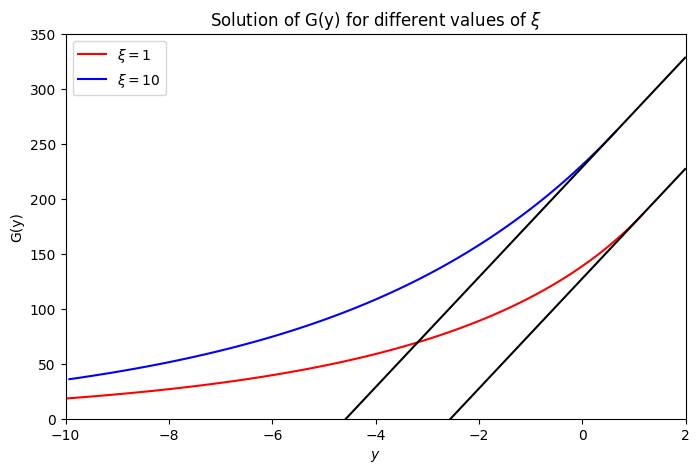

In [ ]:
delta = 0.02  # Example value for delta
sigma = 0.3  # Example value for sigma
alpha = 0.1  # Example value for alpha
I = 10 #  Example boundary value


y_plot=np.arange(-10,2,0.01)
G_1, H_1,y_1,h_1 = one_time_solve(xi=1,y_bar=1.17)
G_10, H_10,y_10,h_10 = one_time_solve(xi=10,y_bar=0.65)
line_xi1=-I+y_plot/delta+alpha/delta**2-sigma**2/(2*1*delta**2)
line_xi10=-I+y_plot/delta+alpha/delta**2-sigma**2/(2*10*delta**2)

plt.figure(figsize=(8, 5))

plt.plot(y_1[y_1>-10], G_1[y_1>-10], label=r'$\xi=1$',color='red')
plt.plot(y_plot, line_xi1,color='black',label=r'$f(y)-I$')
plt.plot(y_10[y_10>-10], G_10[y_10>-10], label=r'$\xi=10$',color='blue')
plt.plot(y_plot, line_xi10,color='black')
# plt.plot(y_0_1[y_0_1>-5], G_0_1[y_0_1>-5], label=r'$\xi=0.1$')

plt.xlabel(r'$y$')
plt.ylabel(r'G(y)')
plt.xlim(-10, 2)
plt.ylim(0, 350)
plt.legend()
plt.title(r'Solution of G(y) for different values of $\xi$')
# plt.savefig('log_G_y.png')
# plt.grid()
plt.show()

In [96]:
### Plot of ybar over xi




import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp




save_list_xi =[]
save_list_y_bar = []
save_list_Gprime = []
save_list_y_list = []
save_list_h_distortion =[]


xi_list = np.arange(1,40,1)
xi_list = np.append(xi_list,10000)
for xi_values in xi_list:


    def one_time_solve(y_bar=15,xi=10000):
        # Define the system of ODEs
        def odes(y, U, delta, sigma, alpha, xi):
            G, H = U
            dG_dy = H
            dH_dy = (2 / sigma**2) * (delta * G - H * alpha + (delta*sigma**2 / (2 * xi)) * H**2)
            return np.vstack([dG_dy, dH_dy])

        # Wrapper function to fix parameters for solve_bvp
        def odes_fixed(y, U):
            return odes(y, U, delta, sigma, alpha, xi)

        # Define boundary conditions
        def bc(Ua, Ub, y_bar, I):
            Ga, Ha = Ua  # Values at left boundary
            Gb, Hb = Ub  # Values at right boundary
            return np.array([Ga, Gb - (y_bar/delta - I+ alpha/delta**2-sigma**2/(2*xi*delta**2))])

        # Wrapper function to fix parameters for solve_bvp
        def bc_fixed(Ua, Ub):
            return bc(Ua, Ub, y_bar, I)

        # Parameters (adjust as needed)
        delta = 0.02  # Example value for delta
        sigma = 0.3  # Example value for sigma
        alpha = 0.1  # Example value for alpha
        I = 10 #  Example boundary value

        # Define the domain for y
        y_min, y_max = -100, y_bar  # Large negative value to approximate -∞
        y = np.linspace(y_min, y_max, 1000)  # Discretize y-space with 100 points

        # Initial guess for G and H
        U_init = np.zeros((2, y.size))

        # Solve the BVP
        sol = solve_bvp(odes_fixed, bc_fixed, y, U_init)

        Gy_sol = sol.y[0]
        Hy_sol = sol.y[1]
        
        h_sol = -sigma/xi * Hy_sol*delta
        
        return Gy_sol, Hy_sol,y,h_sol


    if xi_values<1:
        y_bar_list = np.arange(1, 10, 0.01)
    else:
        y_bar_list = np.arange(0.4, 1.5, 0.01)

    results = []

    for y_bar_value in y_bar_list:
        _,temp_H,_,_ = one_time_solve(y_bar=y_bar_value,xi=xi_values)
        results.append(temp_H)

    results=np.array(results)


    min_index = np.argmin(np.abs(results[:,-1]-1/delta))
    min_result = results[min_index,-1]
    min_y_bar = y_bar_list[min_index]

    save_list_xi.append(xi_values)
    save_list_y_bar.append(min_y_bar)
    print('xi value:',xi_values,'The found value of H(y) is', min_result, 'at y_bar =', min_y_bar)  

    save_list_Gprime.append(one_time_solve(y_bar=min_y_bar,xi=xi_values)[1])
    save_list_y_list.append(one_time_solve(y_bar=min_y_bar,xi=xi_values)[2])
    save_list_h_distortion.append(one_time_solve(y_bar=min_y_bar,xi=xi_values)[3])
    
    
save_list_xi = np.array(save_list_xi)
save_list_y_bar = np.array(save_list_y_bar)
save_list_Gprime = np.array(save_list_Gprime)
save_list_y_list = np.array(save_list_y_list)
save_list_h_distortion = np.array(save_list_h_distortion)


import pandas as pd

# Create a DataFrame
df = pd.DataFrame({"xi": save_list_xi, "y_bar": save_list_y_bar})

# Save as CSV
df.to_csv("model3_solution_xi_ybar.csv", index=False)





xi value: 1 The found value of H(y) is 50.096382795102286 at y_bar = 1.1700000000000008
xi value: 2 The found value of H(y) is 50.01618878007718 at y_bar = 0.8200000000000004
xi value: 3 The found value of H(y) is 50.02844217866318 at y_bar = 0.7400000000000003
xi value: 4 The found value of H(y) is 49.97235738182002 at y_bar = 0.7000000000000003
xi value: 5 The found value of H(y) is 49.9681540847825 at y_bar = 0.6800000000000003
xi value: 6 The found value of H(y) is 49.99387479630753 at y_bar = 0.6700000000000003
xi value: 7 The found value of H(y) is 49.979046720111455 at y_bar = 0.6600000000000003
xi value: 8 The found value of H(y) is 50.042735318319686 at y_bar = 0.6600000000000003
xi value: 9 The found value of H(y) is 49.98994789972922 at y_bar = 0.6500000000000002
xi value: 10 The found value of H(y) is 50.02746049032275 at y_bar = 0.6500000000000002
xi value: 11 The found value of H(y) is 49.9586178250296 at y_bar = 0.6400000000000002
xi value: 12 The found value of H(y) is 

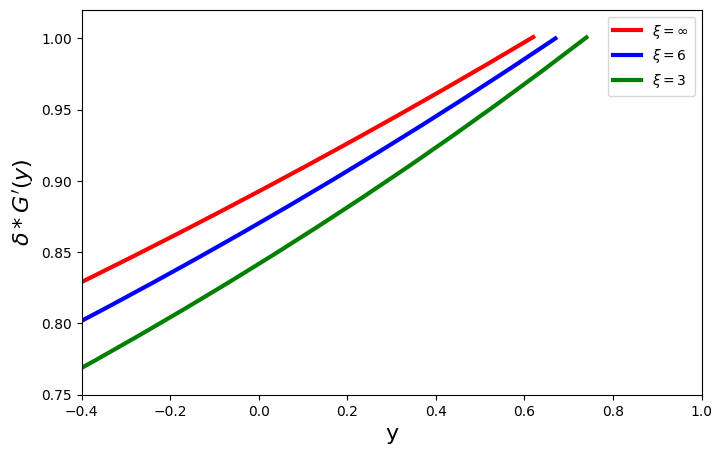

In [98]:

plt.figure(figsize=(8, 5))
plt.plot(save_list_y_list[save_list_xi==10000,:][0,:], delta*save_list_Gprime[save_list_xi==10000,:][0,:], label=r"$\xi=\infty$",linewidth =3,color='r')
plt.plot(save_list_y_list[save_list_xi==6,:][0,:], delta*save_list_Gprime[save_list_xi==6,:][0,:], label=r"$\xi=6$",linewidth =3,color='b')
plt.plot(save_list_y_list[save_list_xi==3,:][0,:], delta*save_list_Gprime[save_list_xi==3,:][0,:], label=r"$\xi=3$",linewidth =3,color='g')
plt.ylabel(r"$\delta*G'(y)$",fontsize=16)
plt.xlabel(r'y',fontsize=16)
plt.xlim(-0.4, 1)
plt.ylim(0.75,1.02)
plt.legend()
plt.savefig("model3_derivative.png")
# plt.title('Solution of the ODE System')
# plt.grid()
plt.show()


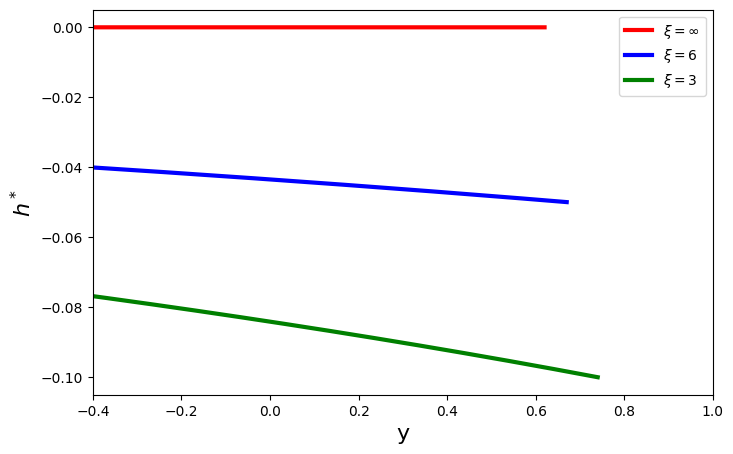

In [99]:

plt.figure(figsize=(8, 5))
plt.plot(save_list_y_list[save_list_xi==10000,:][0,:], save_list_h_distortion[save_list_xi==10000,:][0,:], label=r"$\xi=\infty$",linewidth =3,color='r')
# plt.plot(save_list_y_list[save_list_xi==20,:][0,:], save_list_Gprime[save_list_xi==20,:][0,:], label=r"$\xi=20$",linewidth =3,color='y')
plt.plot(save_list_y_list[save_list_xi==6,:][0,:], save_list_h_distortion[save_list_xi==6,:][0,:], label=r"$\xi=6$",linewidth =3,color='b')
plt.plot(save_list_y_list[save_list_xi==3,:][0,:], save_list_h_distortion[save_list_xi==3,:][0,:], label=r"$\xi=3$",linewidth =3,color='g')
plt.ylabel(r"$h^*$",fontsize=16)
plt.xlabel(r'y',fontsize=16)
plt.xlim(-0.4, 1)
# plt.ylim(0.75,1.02)
plt.legend()
plt.savefig("model3_distortion.png")
# plt.title('Solution of the ODE System')
# plt.grid()
plt.show()



## Exercise Thresholds versus Robustness  

The final section collects the numerical solvers from the two models and reproduces Figure 12 of the paper, which plots  

$$
\bar y(\xi)
$$

for both payoff specifications on the same axes.


In [35]:
import pandas as pd

# Read the CSV file
df_model1 = pd.read_csv("model1_solution_xi_ybar.csv")
df_model3 = pd.read_csv("model3_solution_xi_ybar.csv")

xi_model1 = df_model1["xi"].to_numpy()
ybar_model1 = df_model1["y_bar"].to_numpy()
xi_model3 = df_model3["xi"].to_numpy()
ybar_model3 = df_model3["y_bar"].to_numpy()


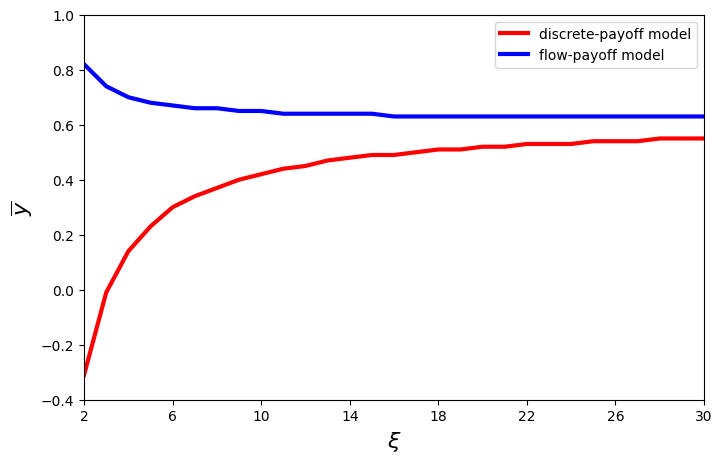

In [69]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8, 5))
plt.plot(xi_model1[xi_model1>=2],ybar_model1[xi_model1>=2],color='red',label='discrete-payoff model',linewidth =3)
plt.plot(xi_model3[xi_model3>=2],ybar_model3[xi_model3>=2],color='blue',label='flow-payoff model',linewidth =3)
plt.xlabel(r'$\xi$',fontsize=16)
plt.ylabel(r'$\overline{y}$',fontsize=16)
plt.xlim(2, 30)
plt.ylim(-0.4,1)
plt.xticks(np.arange(2, 31, 4))  # Force ticks from 2 to 30 with step 2
plt.legend()
# plt.title(r'Solution of $\overline{y}$ for different values of $\xi$')
plt.savefig("threshold_plot.png")
plt.show()

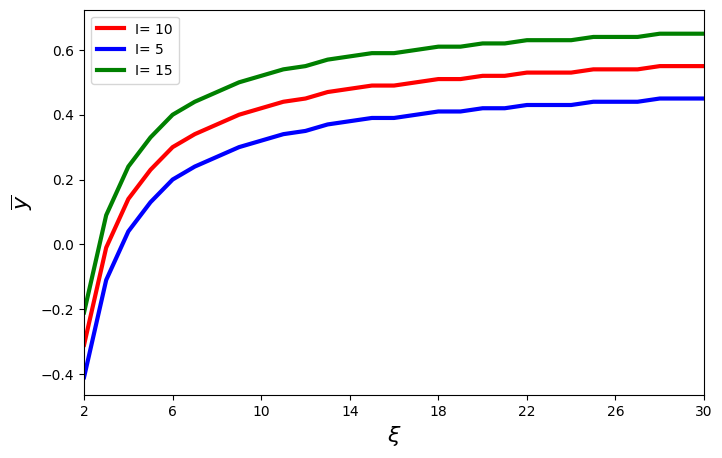

In [66]:
df_model1_I5 = pd.read_csv("model1_solution_xi_ybar_I5.csv")
df_model1_I15 = pd.read_csv("model1_solution_xi_ybar_I15.csv")

xi_model1_I5 = df_model1_I5["xi"].to_numpy()
ybar_model1_I5 = df_model1_I5["y_bar"].to_numpy()
xi_model1_I15 = df_model1_I15["xi"].to_numpy()
ybar_model1_I15 = df_model1_I15["y_bar"].to_numpy()
plt.figure(figsize=(8, 5))
plt.plot(xi_model1[xi_model1>=2],ybar_model1[xi_model1>=2],color='red',label='I= 10',linewidth =3)
plt.plot(xi_model1_I5[xi_model1_I5>=2],ybar_model1_I5[xi_model1_I5>=2],color='blue',label='I= 5',linewidth =3)
plt.plot(xi_model1_I15[xi_model1_I15>=2],ybar_model1_I15[xi_model1_I15>=2],color='g',label='I= 15',linewidth =3)
plt.xlabel(r'$\xi$',fontsize=16)
plt.ylabel(r'$\overline{y}$',fontsize=16)
plt.xlim(2, 30)
plt.xticks(np.arange(2, 31, 4))  # Force ticks from 2 to 30 with step 2
plt.legend()
# plt.title(r'Solution of $\overline{y}$ for different values of $\xi$')
# plt.savefig("threshold_plot.png")
plt.show()